In [9]:
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv('scores_data.csv')
df.head(5)

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [18]:
df.describe()

,Batch,User_ID,Score
count,149,149,149
unique,3,149,8
top,AI_ELITE_7,uid_149,4 / 7
freq,53,1,40


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Batch    149 non-null    object
 1   User_ID  149 non-null    object
 2   Score    149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB


In [11]:
df.isnull().sum()

Batch          0
User_ID        0
   Score       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns = df.columns.str.strip()
df.columns

Index(['Batch', 'User_ID', 'Score'], dtype='object')

In [22]:
marks_split = df['Score'].str.split(' ')

In [36]:
marks_split

0      [6, /, 7]
1      [6, /, 7]
2      [7, /, 7]
3      [7, /, 7]
4      [4, /, 7]
         ...    
144    [4, /, 7]
145    [4, /, 7]
146    [4, /, 7]
147    [3, /, 7]
148    [2, /, 7]
Name: Score, Length: 149, dtype: object

In [33]:
marks_split.__class__

pandas.core.series.Series

In [37]:
df['Score'] = marks_split.str[0]

In [39]:
df['Score'] = df['Score'].astype('int')

In [40]:
df['Score']

0      6
1      6
2      7
3      7
4      4
      ..
144    4
145    4
146    4
147    3
148    2
Name: Score, Length: 149, dtype: int64

In [42]:
df.groupby('Batch')['User_ID'].count()

Batch
AI_ELITE_4    48
AI_ELITE_6    48
AI_ELITE_7    53
Name: User_ID, dtype: int64

In [43]:
tot_elite4 = 48
tot_elite6 = 48
tot_elite7 = 53

In [47]:
df.groupby('Batch')['Score'].sum()

Batch
AI_ELITE_4    182
AI_ELITE_6    203
AI_ELITE_7    268
Name: Score, dtype: int64

In [ ]:
# Finding the batch performance
(df.groupby('Batch')['Score'].sum()/(df.groupby('Batch')['User_ID'].count() * 7) * 100).round(2)

Batch
AI_ELITE_4    54.17
AI_ELITE_6    60.42
AI_ELITE_7    72.24
dtype: float64

- AI_ELITE_7 is the best performer in this exam

In [68]:
# best performers of every batch
st_elite4 = df[df['Batch'] == 'AI_ELITE_4']
st_elite6 = df[df['Batch'] == 'AI_ELITE_6']
st_elite7 = df[df['Batch'] == 'AI_ELITE_7']

In [129]:
max_scores = df.groupby('Batch')['Score'].max().tolist() # finding the highest marks for each batch
max_scores

[7, 7, 7]

In [107]:
# Best performers of elite 4
best_performers_elite4 = st_elite4[st_elite4['Score'] == max_scores[0]]['User_ID'].tolist()
best_performers_elite4

['uid_48', 'uid_44', 'uid_10']

In [108]:
# Best performers of elite 6
best_performers_elite6 = st_elite6[st_elite6['Score'] == max_scores[1]]['User_ID'].tolist()
best_performers_elite6

['uid_86', 'uid_82', 'uid_75', 'uid_71', 'uid_51']

In [109]:
# Best performers of elite 7
best_performers_elite7 = st_elite7[st_elite7['Score'] == max_scores[2]]['User_ID'].tolist()
best_performers_elite7

['uid_147',
 'uid_146',
 'uid_144',
 'uid_142',
 'uid_134',
 'uid_133',
 'uid_132',
 'uid_130',
 'uid_125',
 'uid_114']

In [130]:
# poor performer of every batch
lowest_scores = df.groupby('Batch')['Score'].min().to_list() # finding the lowest marks for each batch
lowest_scores

[0, 0, 2]

In [90]:
# Poor performers of elite 4
poor_performers_elite4 = st_elite4[st_elite4['Score'] == lowest_scores[0]]['User_ID'].tolist()
poor_performers_elite4

['uid_14']

In [91]:
# Poor performers of elite 6
poor_performers_elite6 = st_elite6[st_elite6['Score'] == lowest_scores[1]]['User_ID'].tolist()
poor_performers_elite6

['uid_81']

In [92]:
# Poor performers of elite 7
poor_performers_elite7 = st_elite7[st_elite7['Score'] == lowest_scores[2]]['User_ID'].tolist()
poor_performers_elite7

['uid_112', 'uid_99']

#### percentage segmentation for each batch (students under 40%, 60%, 75%, 90%, above 90)

In [83]:
total_marks = 7
m40 = round(0.4 * total_marks)
m60 = round(0.6 * total_marks)
m75 = round(0.75 * total_marks)
m90 = round(0.9 * total_marks)
print(m40, m60, m75, m90)

3 4 5 6


In [98]:
# For batch elite 4
elite4_below_40 = int(st_elite4[st_elite4['Score'] < m40]['User_ID'].count())
elite4_below_60 = int(st_elite4[(st_elite4['Score'] < m60) & (st_elite4['Score'] >= m40)]['User_ID'].count())
elite4_below_75 = int(st_elite4[(st_elite4['Score'] < m75) & (st_elite4['Score'] >= m60)]['User_ID'].count())
elite4_below_90 = int(st_elite4[(st_elite4['Score'] < m90) & (st_elite4['Score'] >= m75)]['User_ID'].count())
elite4_above_90 = int(st_elite4[st_elite4['Score'] >= m90]['User_ID'].count())
elite4_below_40, elite4_below_60, elite4_below_75, elite4_below_90, elite4_above_90

(9, 8, 19, 8, 4)

In [ ]:
# For batch elite 6
elite6_below_40 = int(st_elite6[st_elite6['Score'] < m40]['User_ID'].count())
elite6_below_60 = int(st_elite6[(st_elite6['Score'] < m60) & (st_elite6['Score'] >= m40)]['User_ID'].count())
elite6_below_75 = int(st_elite6[(st_elite6['Score'] < m75) & (st_elite6['Score'] >= m60)]['User_ID'].count())
elite6_below_90 = int(st_elite6[(st_elite6['Score'] < m90) & (st_elite6['Score'] >= m75)]['User_ID'].count())
elite6_above_90 = int(st_elite6[st_elite6['Score'] >= m90]['User_ID'].count())
elite6_below_40, elite6_below_60, elite6_below_75, elite6_below_90, elite6_above_90

(6, 9, 11, 13, 9)

In [100]:
# For batch elite 7
elite7_below_40 = int(st_elite7[st_elite7['Score'] < m40]['User_ID'].count())
elite7_below_60 = int(st_elite7[(st_elite7['Score'] < m60) & (st_elite7['Score'] >= m40)]['User_ID'].count())
elite7_below_75 = int(st_elite7[(st_elite7['Score'] < m75) & (st_elite7['Score'] >= m60)]['User_ID'].count())
elite7_below_90 = int(st_elite7[(st_elite7['Score'] < m90) & (st_elite7['Score'] >= m75)]['User_ID'].count())
elite7_above_90 = int(st_elite7[st_elite7['Score'] >= m90]['User_ID'].count())
elite7_below_40, elite7_below_60, elite7_below_75, elite7_below_90, elite7_above_90

(2, 7, 10, 11, 23)

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Batch wise performance')

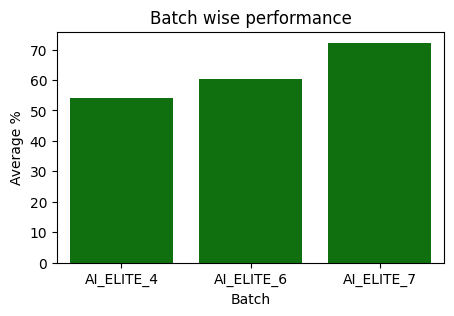

In [105]:
batch_wise_perf = (df.groupby('Batch')['Score'].mean() / total_marks) * 100
plt.figure(figsize=(5,3))
sns.barplot(batch_wise_perf, color = 'green')
plt.ylabel('Average %')
plt.xlabel('Batch')
plt.title('Batch wise performance')

In [110]:
batch_wise_perf

Batch
AI_ELITE_4    54.166667
AI_ELITE_6    60.416667
AI_ELITE_7    72.237197
Name: Score, dtype: float64

In [112]:
# Max and Min
minmax = {
    'Minimum': lowest_scores,
    'Maximum': max_scores,
    'Batch': batch_wise_perf.index
}
minmaxdf = pd.DataFrame(minmax)
minmaxdf

,Minimum,Maximum,Batch
0,0,7,AI_ELITE_4
1,0,7,AI_ELITE_6
2,2,7,AI_ELITE_7


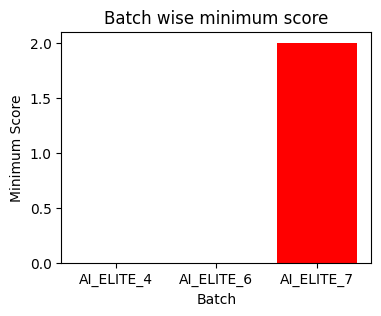

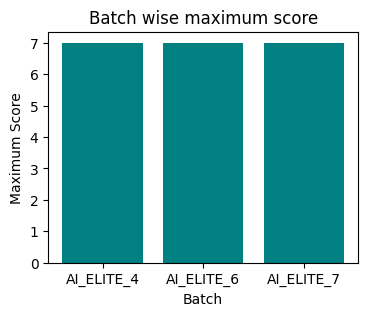

In [132]:
plt.figure(figsize=(4,3))
plt.bar(minmaxdf['Batch'], minmaxdf['Minimum'], color='red')
plt.xlabel('Batch')
plt.ylabel('Minimum Score')
plt.title('Batch wise minimum score')
plt.show()
plt.figure(figsize=(4,3))
plt.bar(minmaxdf['Batch'], minmaxdf['Maximum'], color='teal')
plt.xlabel('Batch')
plt.ylabel('Maximum Score')
plt.title('Batch wise maximum score')
plt.show()

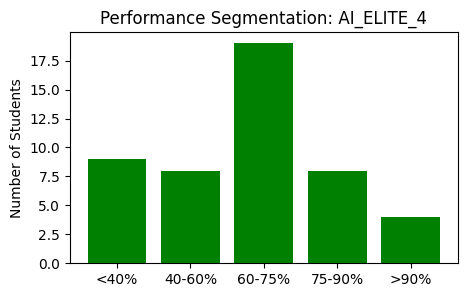

In [125]:
labels = ['<40%', '40-60%', '60-75%', '75-90%', '>90%']
values = [elite4_below_40, elite4_below_60, elite4_below_75, elite4_below_90, elite4_above_90]
plt.figure(figsize=(5,3))
plt.bar(labels, values, color = 'green')
plt.ylabel('Number of Students')
plt.title('Performance Segmentation: AI_ELITE_4')
plt.show()

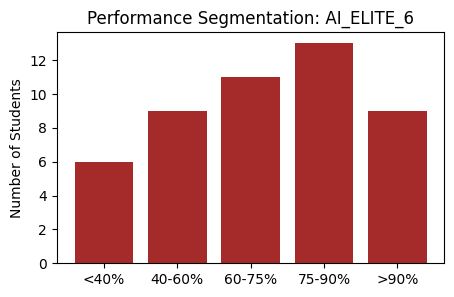

In [127]:
labels = ['<40%', '40-60%', '60-75%', '75-90%', '>90%']
values = [elite6_below_40, elite6_below_60, elite6_below_75, elite6_below_90, elite6_above_90]
plt.figure(figsize=(5,3))
plt.bar(labels, values, color = 'brown')
plt.ylabel('Number of Students')
plt.title('Performance Segmentation: AI_ELITE_6')
plt.show()

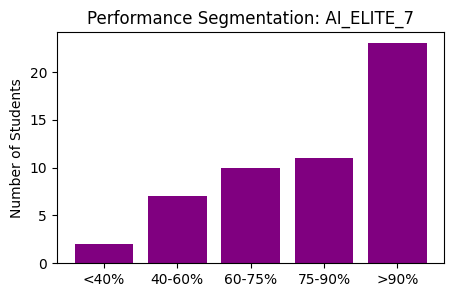

In [128]:
labels = ['<40%', '40-60%', '60-75%', '75-90%', '>90%']
values = [elite7_below_40, elite7_below_60, elite7_below_75, elite7_below_90, elite7_above_90]
plt.figure(figsize=(5,3))
plt.bar(labels, values, color = 'purple')
plt.ylabel('Number of Students')
plt.title('Performance Segmentation: AI_ELITE_7')
plt.show()